# Environment Setup & Dependencies

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler

# Reading the Dataset

In [2]:
# Convert messy semicolon-separated file to a clean, standard CSV
df = pd.read_csv("data/cardio_train.csv", sep=";")
df.to_csv("data/cardio_train_cleaned.csv", index=False)
print("Clean CSV file saved successfully!")

Clean CSV file saved successfully!


In [3]:
df = pd.read_csv("data/cardio_train_cleaned.csv")
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [4]:
df.isnull().sum()

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

In [5]:
df.info()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


(70000, 13)

In [6]:
df = df.drop('id', axis=1)
df["age"] = df["age"] // 365

df.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,50,2,168,62.0,110,80,1,1,0,0,1,0
1,55,1,156,85.0,140,90,3,1,0,0,1,1
2,51,1,165,64.0,130,70,3,1,0,0,0,1
3,48,2,169,82.0,150,100,1,1,0,0,1,1
4,47,1,156,56.0,100,60,1,1,0,0,0,0


# Data Visualizations

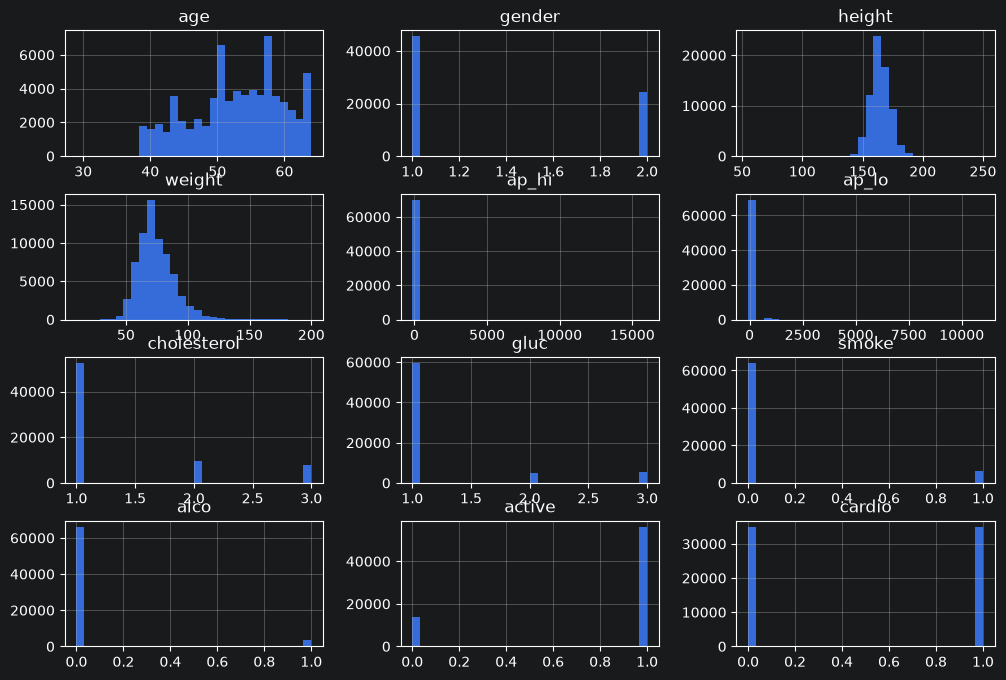

In [7]:
df.hist(figsize=(12, 8), bins=30)  # Creates histograms for all numerical columns
plt.show()

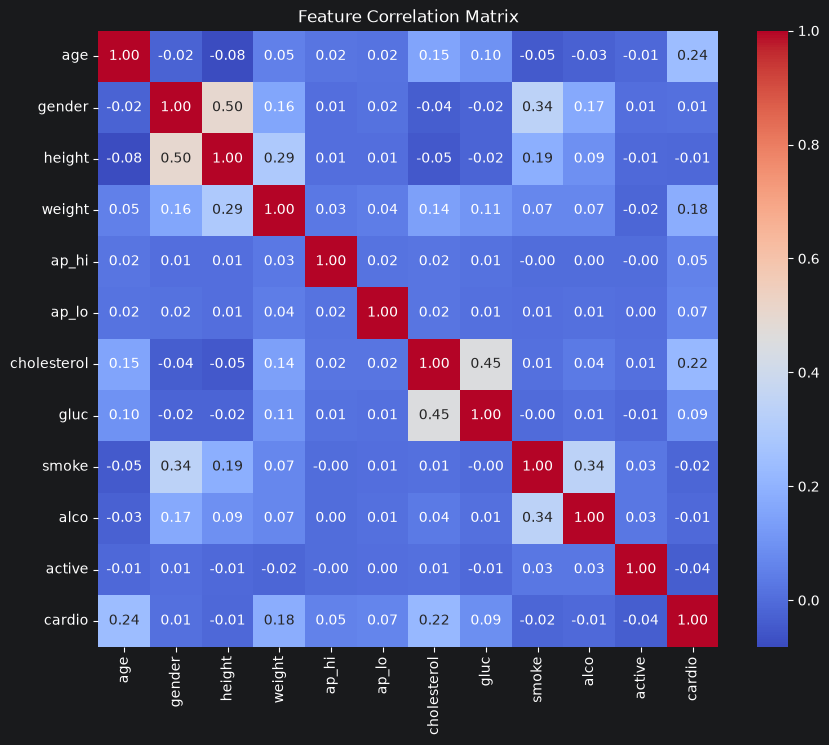

In [8]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

# Train-Test Split

In [9]:
x = df.drop('cardio', axis=1)
y = df['cardio']

y.value_counts()

cardio
0    35021
1    34979
Name: count, dtype: int64

In [10]:
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42, stratify=y, test_size=0.2)

In [11]:
print(y_train.value_counts())
print(y_test.value_counts())

cardio
0    28017
1    27983
Name: count, dtype: int64
cardio
0    7004
1    6996
Name: count, dtype: int64


# Feature Scaling

In [12]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# Trying Out Different Models

In [13]:
models = {
  "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVC": SVC(),
    "KNN": KNeighborsClassifier()
}

In [14]:
cv_scores = {}

best_model = None
best_score = 0

for model_name, model in models.items():
    print(f"Training {model_name} with default parameters")
    scores = cross_val_score(model, x_train, y_train, cv=5, scoring="accuracy")
    mean_score = np.mean(scores)
    cv_scores[model_name] = scores
    print(f"{model_name} cross validation accuracy: {np.mean(scores):.2f}")
    print("-"*50)

    if mean_score > best_score:
        best_score = mean_score
        best_model = model_name

print(f"\nBest Model: {best_model} with accuracy: {best_score:.2f}")

Training Logistic Regression with default parameters
Logistic Regression cross validation accuracy: 0.72
--------------------------------------------------
Training Decision Tree with default parameters
Decision Tree cross validation accuracy: 0.64
--------------------------------------------------
Training Random Forest with default parameters
Random Forest cross validation accuracy: 0.71
--------------------------------------------------
Training SVC with default parameters
SVC cross validation accuracy: 0.73
--------------------------------------------------
Training KNN with default parameters
KNN cross validation accuracy: 0.64
--------------------------------------------------

Best Model: SVC with accuracy: 0.73


In [15]:
cv_scores

{'Logistic Regression': array([0.71732143, 0.72830357, 0.72089286, 0.71321429, 0.72375   ]),
 'Decision Tree': array([0.64116071, 0.64339286, 0.64107143, 0.631875  , 0.63901786]),
 'Random Forest': array([0.70857143, 0.71285714, 0.70464286, 0.70714286, 0.71866071]),
 'SVC': array([0.72339286, 0.73723214, 0.71803571, 0.72321429, 0.733125  ]),
 'KNN': array([0.63883929, 0.65      , 0.63723214, 0.63901786, 0.65017857])}

# Using the Best Model

In [16]:
best_model = SVC(probability=True, random_state=42)
best_model.fit(x_train, y_train)

,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",True
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [18]:
y_test_pred = best_model.predict(x_test)
y_test_proba = best_model.predict_proba(x_test)[:, 1]

print(f"Accuracy Score: {accuracy_score(y_test, y_test_pred) * 100:.2f}%")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_test_proba) * 100:.2f}%")
print("Classification Report:\n", classification_report(y_test, y_test_pred))

Accuracy Score: 72.43%
ROC-AUC Score: 78.20%
Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.76      0.73      7004
           1       0.74      0.69      0.72      6996

    accuracy                           0.72     14000
   macro avg       0.73      0.72      0.72     14000
weighted avg       0.73      0.72      0.72     14000



In [19]:
sample_idx = 0

sample_pred = best_model.predict(x_test[sample_idx].reshape(1, -1))[0]

if sample_pred == 0:
    print("Prediction: The person does NOT have Cardiovascular Disease (CVD).")
else:
    print("Prediction: The person HAS Cardiovascular Disease (CVD).")

Prediction: The person does NOT have Cardiovascular Disease (CVD).


# Saving the Model

In [20]:
os.makedirs("models", exist_ok=True)

joblib.dump(scaler, "models/scaler.joblib")
joblib.dump(best_model, "models/svc_model.joblib")
print("All model artifacts successfully exported to models/")

All model artifacts successfully exported to models/
